In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Checking missing values

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Checking duplicte values

df.duplicated().sum()

np.int64(0)

In [8]:
# Count customers who left and who stayed
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
# Calculate the churn rate
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 26.54%


In [10]:
# Churn rate by contract type

contract_churn = pd.crosstab(          # Creats a summary table
    df["Contract"],                    # groups customers by contract type
    df["Churn"],                       # counts customers who stayed or left
    normalize = "index")*100           # converts the counts into percentage for each contract group
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<function matplotlib.pyplot.show(close=None, block=None)>

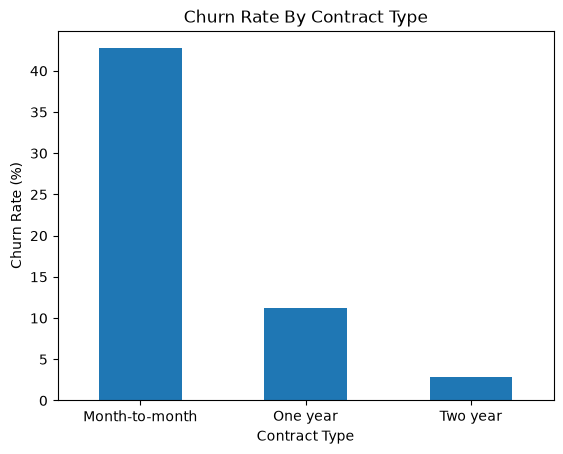

In [11]:
import matplotlib.pyplot as plt

contract_churn["Yes"].plot(
    kind = 'bar', title = 'Churn Rate By Contract Type',
    ylabel = 'Churn Rate (%)',
    xlabel = "Contract Type"
)
plt.xticks(rotation=0)
plt.show

In [12]:
# CHURN rate by monthly charges
# this code calculates the average monthly bill for customers who stayed and customers who left

monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()
monthly_charges_churn

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

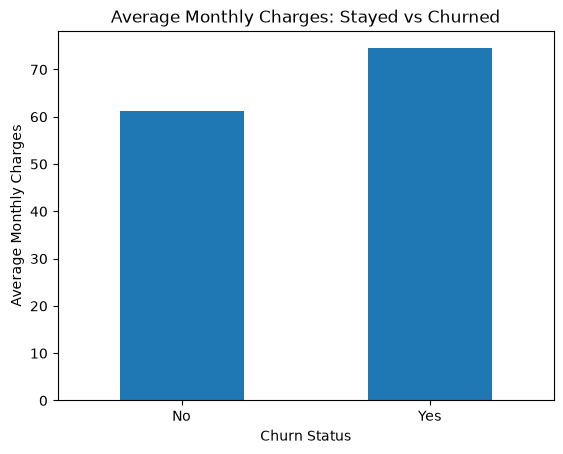

In [13]:
# Average monthly charges by churn status

monthly_charges_churn.plot(
    kind = 'bar',
    title = "Average Monthly Charges: Stayed vs Churned",
    ylabel = "Average Monthly Charges",
    xlabel = "Churn Status"
)
plt.xticks(rotation=0)
plt.show()

In [14]:
# Churn rate by tenure group

def tenure_group(tenure):
    if tenure <= 12:
        return "0 - 12 months"
    elif tenure <= 24:
        return "13 - 24 months"
    elif tenure <= 48:
        return "25 - 48 months"
    else :
        return "49+ months"

df["TenureGroup"] = df["tenure"].apply(tenure_group)             # .apply() runs a function on each value in a pandas column.
tenure_churn = df.groupby("TenureGroup")["Churn"].apply(         # This groups all customers who belong to the same tenure category.
    lambda x: (x == "Yes").mean() * 100 
)
tenure_churn

TenureGroup
0 - 12 months     47.438243
13 - 24 months    28.710938
25 - 48 months    20.388959
49+ months         9.513176
Name: Churn, dtype: float64

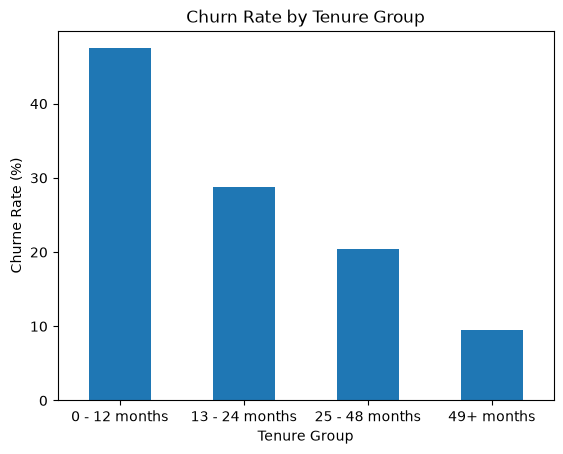

In [15]:
# Churn rate by tenure group

tenure_churn.plot(
    kind = 'bar',
    title = "Churn Rate by Tenure Group",
    ylabel = "Churne Rate (%)",
    xlabel = "Tenure Group"
)
plt.xticks(rotation = 0)
plt.show()

In [16]:
# Churn rate by internet services

internet_churn = df.groupby("InternetService")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100)
internet_churn

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

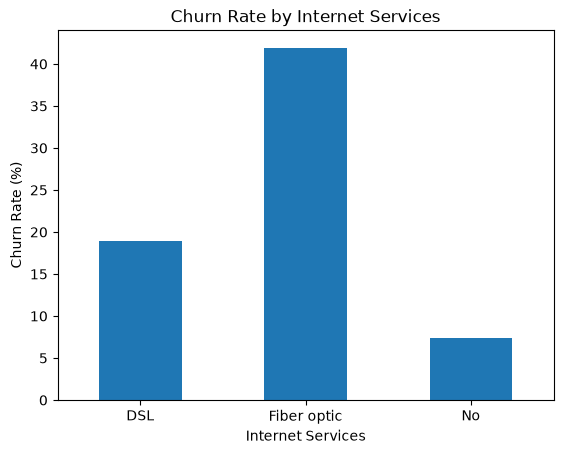

In [17]:
internet_churn.plot(
    kind = "bar",
    title = "Churn Rate by Internet Services",
    ylabel = "Churn Rate (%)",
    xlabel = "Internet Services"
)
plt.xticks(rotation = 0)
plt.show()

### Customers using fiber optic internet have the highest churn rate at approximately 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service. The company should investigate fiber optic pricing, service quality, technical issues, and customer support experience.

In [18]:
# Churn Rate by payment method

payment_churn = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100)
payment_churn

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn, dtype: float64

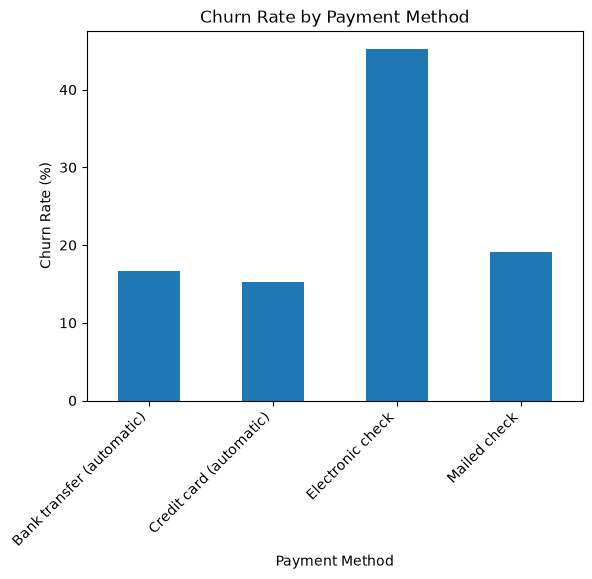

In [19]:
payment_churn.plot(
    kind = "bar",
    title = "Churn Rate by Payment Method",
    ylabel = "Churn Rate (%)",
    xlabel = "Payment Method"
)
plt.xticks(rotation = 45, ha = "right")
plt.show()

### Customers using electronic checks have the higest churn rate at approximately 45.29%. Customers using automatic credict card and automatic bank transfer payments have lower churn rates of approximately 15.24% and 16.71%, respectively. The company should investigate electronic_check billing issues and encourage convenient automatic payment options.

In [20]:
# Churn rate by seniour citizen status

senior_churn = df.groupby("SeniorCitizen")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100)
senior_churn

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

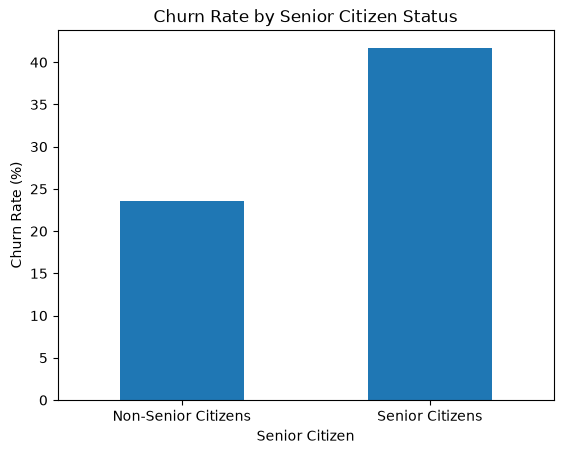

In [21]:
senior_churn.plot(
    kind = "bar",
    title = "Churn Rate by Senior Citizen Status",
    ylabel = "Churn Rate (%)",
    xlabel = "Senior Citizen"
)
plt.xticks(ticks = [0,1],
           labels = ["Non-Senior Citizens", "Senior Citizens"],
           rotation = 0
          )
plt.show()

### Senior citizens have a churn rate of approximately 41.68%, compared with 23.61% for non-senior customers. The company should investigate whether senior customers need additional support, simpler service plans, clearer billing communication, or personalized retention assistance.

In [22]:
# Churn rate by partner status

partner_churn = df.groupby("Partner")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100)
partner_churn

Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64

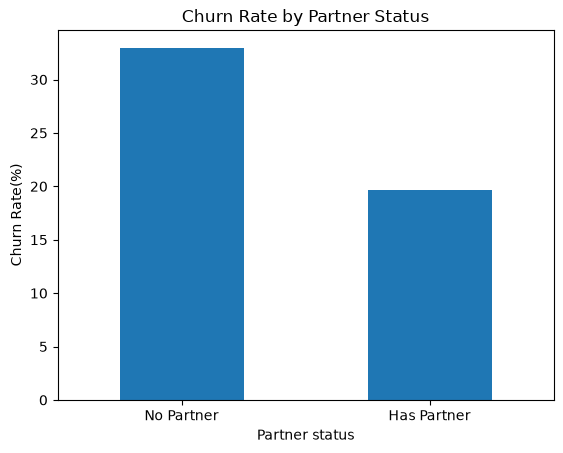

In [23]:
partner_churn.plot(
    kind = "bar",
    title = "Churn Rate by Partner Status",
    ylabel = "Churn Rate(%)",
    xlabel = "Partner status")
plt.xticks(ticks = [0,1],
           labels = ["No Partner", "Has Partner"],
           rotation = 0)
plt.show()

### Customers without a partner have a churn rate of approximately 32.96%, compared with 19.66% for customers with a partner. The company should provide stronger engagement, loyalty benefits, and personalized support for customers who may have fewer household-related reasons to remain with the service.

In [24]:
# Churn rate by dependents

dependents_churn = df.groupby("Dependents")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100)
dependents_churn

Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64

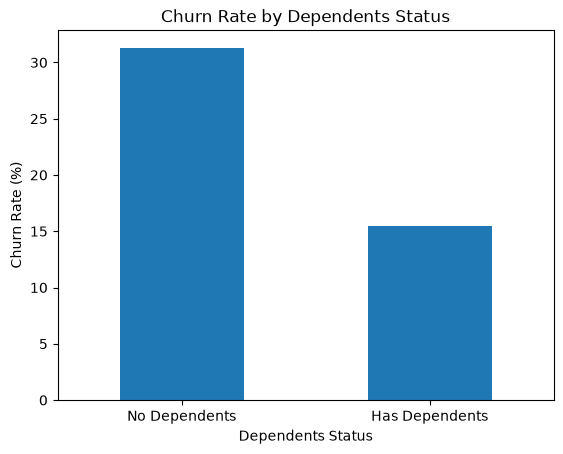

In [25]:
dependents_churn.plot(
    kind = "bar",
    title = "Churn Rate by Dependents Status",
    ylabel = "Churn Rate (%)",
    xlabel = "Dependents Status"
)
plt.xticks(ticks = [0,1],
           labels = ["No Dependents", "Has Dependents"],
           rotation = 0
          )
plt.show()

### Customers without dependents have a churn rate of approximately 31.28%, compared with 15.45% for customers with dependents. The company should consider personalized engagement, loyalty benefits, and retention offers for customers without dependents.


In [26]:
# Churn rate by contract type

contract_churn =  df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100)
contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

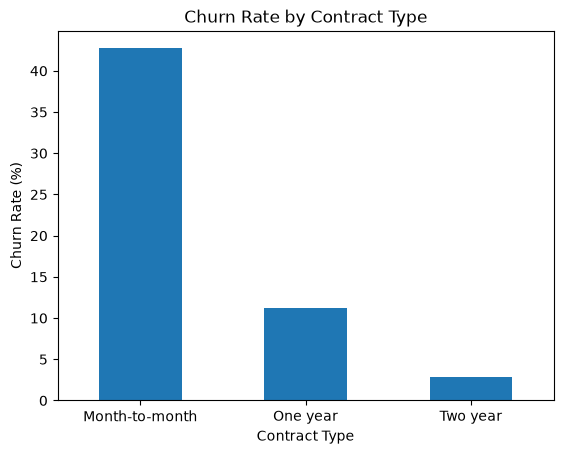

In [27]:
contract_churn.plot(
    kind = "bar",
    title = "Churn Rate by Contract Type",
    ylabel = "Churn Rate (%)",
    xlabel = "Contract Type"
)
plt.xticks(rotation = 0)
plt.show()

### Month-to-month customers have the highest churn rate at approximately 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. The company should focus on converting month-to-month customers into longer-term plans through transparent pricing, flexible upgrade options, loyalty benefits, and suitable contract incentives.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [29]:
# Check the TotalCharges column
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [30]:
# Check tthe datatype of total charges
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [31]:
# Convert the total charges from string (text) to numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors = "coerce")
df["TotalCharges"].dtype

dtype('float64')

In [32]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [33]:
# Display rows where total charges is missing

df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [34]:
# fill missing TotalCharges values with 0

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# check weather missing values remain
df["TotalCharges"].isna().sum()

np.int64(0)

In [35]:
# Verify that missing values in totalCharges afre replaced with 0

df[df["tenure"] == 0][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [36]:
df["TotalCharges"].dtype

dtype('float64')

### The 11 missing TotalCharges values were associated with customers having zero tenure. These customers were treated as new customers with no accumulated charges, so the missing values were replaced with zero.

In [37]:
# Convert Churn from yes no into 1/0

df["Churn"] = df["Churn"].map({
    "No" : 0,
    "Yes" : 1})
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [38]:
# Check the unique values in churn
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [41]:
churn_rate = df["Churn"].mean() * 100
print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 26.54%


In [40]:
# Checking for missing values in churn
df["Churn"].isna().sum()

np.int64(0)

In [41]:
# CHeckk datatypes after cleaning
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
TenureGroup             str
dtype: object

In [42]:
# Remove identifier and EDA_only columns

df_ml = df.drop(columns = ["customerID", "TenureGroup"])
# Display the remaining columns
df_ml.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [43]:
df_ml.shape

(7043, 20)

In [44]:
# Saperate input Features and target varibles

x = df_ml.drop(columns = ["Churn"])    
y = df_ml["Churn"]

# Check their shapes
print("Features shape:", x.shape) 
print("Target shape:", y.shape)

# X contains the information used to predict churn, such as: Gender, Tenure, MOnthly Charges, Total Charges, Contract, Payment method, Internet services
# Y Contains the answer that we want to predict: 
# 0 = Customer Stayed
# 1 = Customer Churned

Features shape: (7043, 19)
Target shape: (7043,)


In [45]:
# Identify the mathematical and categorical columns

numeric_columns = x.select_dtypes(
    include =["int64", "float64"]).columns

categorical_columns = x.select_dtypes(
    include = ["str", "object"]).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical_columns:")
print(list(categorical_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical_columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [46]:
# Convert Categorical into numerical columns

x_encoded = pd.get_dummies(
    x,
    columns = categorical_columns,
    drop_first = True,
    dtype = int
)
# Check the new shape

print("Encoded features Shape:", x_encoded.shape)
# x_encoded.shape then we will split the data into training and testing sets

Encoded features Shape: (7043, 30)


In [47]:
# Display the first five rows of encoded features

x_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [48]:
# Check weather all encoded columns are numeric

x_encoded.dtypes.value_counts()

int64      28
float64     2
Name: count, dtype: int64

In [49]:
# Split the data into training and testing sets
# 80% of data for training 
# 20% of data for testing

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

# Check the shapes

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("Y_train shape:", y_train.shape)
print("Y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
Y_train shape: (5634,)
Y_test shape: (1409,)


In [50]:
# Check churn distribution in training and testing data

print("Training churn distribution:")
print(y_train.value_counts(normalize = True)*100)
print("\nTesting Churn distribution:")
print(y_test.value_counts(normalize = True)*100)

Training churn distribution:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing Churn distribution:
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [51]:
from sklearn.linear_model import LogisticRegression



In [52]:
# Creat the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter = 1000,
    random_state = 42)


In [53]:
# Train model using the training data

logistic_model.fit(x_train, y_train)
print("Logistic Regression model trained sucessfully!")


Logistic Regression model trained sucessfully!


C:\Users\vamsikrishna\anaconda3\envs\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
# creat a scaler
scaler = StandardScaler()

# this creat tools named scaler. it has not changed the data yet

In [56]:
# learn scalling values from training data

x_train_scaled = scaler.fit_transform(x_train)

# apply the same scalling values to testing data

x_test_scaled = scaler.transform(x_test)

In [57]:
# Creat logistic Regression with more iterstions

logistic_model_scaled = LogisticRegression(
    max_iter = 2000,
    random_state = 42)

# logistic_modl_scaled is the name of our new model
# max_iter = 2000 allow up to 2000 learning iterations
# random_state = 42 keep the result repeatable

In [58]:
# Train the scaled logistic regression model

logistic_model_scaled.fit(
    x_train_scaled,
    y_train)
print ("Scaled Logistic Regression model trained sucessfully!")

Scaled Logistic Regression model trained sucessfully!


In [59]:
y_pred = logistic_model_scaled.predict(x_test_scaled)
print("Prediction generated sucessfully!")

# logistic_model_scaled ----> our trained logistic regression model
# .predict() -----> ask the model to make predictions
# x_test_scaled ------> the 20% test data that the model has never trained on
# y_pred ----> stores the prediction

Prediction generated sucessfully!


In [60]:
print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [61]:
print("Total test customers: ", len(y_pred))
print("Predicted no churn:", (y_pred == 0).sum())
print("Prediction churn:", (y_pred == 1).sum())

Total test customers:  1409
Predicted no churn: 1087
Prediction churn: 322


In [62]:
len(y_pred)

1409

In [63]:
(y_pred == 0).sum()

np.int64(1087)

In [64]:
(y_pred == 1).sum()

np.int64(322)

In [65]:
# Now we are going to evaluate the model

from sklearn.metrics import accuracy_score
# We're importing Scikit-learn's accuracy_score function.

accuracy = accuracy_score(y_test, y_pred)
# Comparing Actual values(y_test) vs Predicted values(y_pred)

print("Accuracy:", accuracy)
# shows the accuracy as a decimal

print("Accuracy percentage:", accuracy * 100)
# converts it into percentage

Accuracy: 0.8069552874378992
Accuracy percentage: 80.69552874378992


In [66]:
# Now we are going to calculate precision, Recall and F1-source

from sklearn.metrics import precision_score, recall_score, f1_score
# we are importing three evalution function from scikit-learner.


precision = precision_score(y_test, y_pred)
# Comparing the actual churn values (y_test) with the predicted churn values (y_pred)
# to calculate precision

recall = recall_score(y_test, y_pred)
# comparing actual values with predicted values to calculate recall

f1 = f1_score(y_test, y_pred)
# Calculating the f1_score using the actual and predicted values

print("Precision:", precision)
# Shows precision as a decimal

print("Precision percentage:", precision * 100)
# Convert precision into percentage 

print("Recall:", recall)
# Convertrecall as decimal

print("Recall Percentage:", recall * 100)
# COnverts recall into percentage

print("F1-Score:", f1)

print("F1-Score Percentage:", f1 * 100)

Precision: 0.6583850931677019
Precision percentage: 65.83850931677019
Recall: 0.5668449197860963
Recall Percentage: 56.68449197860963
F1-Score: 0.6091954022988506
F1-Score Percentage: 60.91954022988506


In [67]:
# Now we are going to creat a confusion matrix

from sklearn.metrics import confusion_matrix
# we are importing confusion_matrix from scikit-learn
# it compares the actual values (y_test)
# with the predicted values (y_pred)

cm = confusion_matrix(y_test, y_pred)
# creating the confusion matrix by comparing
# y_test ----> actual churn values
# y_pred ----> predicted churn values

print("Confusion Matrix:")
print(cm)
# Display the four predictions categories:
# True NEgative (TN)
# False Positive (FP)
# False Negative (FN)
# True Positive (TP)

Confusion Matrix:
[[925 110]
 [162 212]]


In [68]:
# Now we are going to creat a classification Report
# why are we doing this?
# THe classification report gives us precision, recall and f1_score
# for both No churn(0) and churn(1)
# it also shows support, which tells us how many actual customers belong to each class in our test data

from sklearn.metrics import classification_report
# We are importing classification report from sklearn.
# it compare the actual values(y_test) with the predicted values(y_pred)

report = classification_report(y_test, y_pred)
# Creating the classification report by comparing: y_test and y_pred ( actual churn values and predicted churn values)

print("Classification Report:")
print(report)
# Displaying the precision, recall, f1_score and support for both no churn and churn

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [69]:
# Now we are going to train Decision tree classifier
# Why are we doing this?
# We already trained and evaluated logistical Regression.
# Now we want another model so that we can lateer compare the performence of diffrent ml algorithoms
# Decision tree are useful because they learn the decision rules

from sklearn.tree import DecisionTreeClassifier


In [70]:
# Here we are going to create a decission tree model
# we imported decision tree classifier int the previous step
# Now we need to create an actual model object that we can train
# Using our training data

decision_tree_model = DecisionTreeClassifier(
    random_state = 42,
    max_depth = 5
)

# random_state = 42 -------> keeps the results reproducible
# It means we get the same result when we run the model again
# max_depth = 5 ------> limits the amximum depth of the tree to 5 levels
# We are limiting the depth because a very deep decision tree can memorize the training data

print("Decision Tree Model created successfully!")

Decision Tree Model created successfully!


In [71]:
# Train the decision tree model
# creating the model only gives the empty decision tree we now need to give it our traing data so that it can learn the patterns between customer information and churn

decision_tree_model.fit(
    x_train, y_train
)

# x_train -----> containd the customer features used for training (Customer information)
# y_train -----> contains the actual churn values for those customers ( actual churn outcomes)
# The .fit() function train decision tree using x_train, y_train

print("Decision Tree model trained sucessfully!")

Decision Tree model trained sucessfully!


In [72]:
# Making decision tree predictions
# the mpdel has learned patterns from x_train, Y_train now we see how well it predicts the customers
# We use x_test insted of x_train because we want to evaluate how well the model works
# x_test contains the test customers

dt_y_pred = decision_tree_model.predict(x_test)
print("Decision Tree predictions generated successfully!")

Decision Tree predictions generated successfully!


In [73]:
# Calcualte decision tree accuracy

dt_accuracy = accuracy_score(y_test, dt_y_pred)
print("Decision Tree accuracy:", dt_accuracy)
print("Decision Tree accuracy percentage:", dt_accuracy * 100)

Decision Tree accuracy: 0.794180269694819
Decision Tree accuracy percentage: 79.4180269694819


In [74]:
# Calculate decision tree precision, recall, f1_score
# Accuracy only tells us the overall percentage of correct predictions

dt_precision = precision_score(y_test, dt_y_pred)
# Comparing actial churn values (y_test) with dection tree predictions(dt_y_pred) to cal culate precisions

dt_recall = recall_score(y_test, dt_y_pred)

dt_f1 = f1_score(y_test, dt_y_pred)

print("Decision Tree Precision:", dt_precision)
print("Decision Tree Precision percentage:", dt_precision * 100)

print("Decision Tree Recall:", dt_recall)
print("Decision Tree Recall percentage:", dt_recall * 100)

print("Decision Tree Fl-score:", dt_f1)
print("Decision Tree F1-score percentage:", dt_f1 * 100)

Decision Tree Precision: 0.63125
Decision Tree Precision percentage: 63.125
Decision Tree Recall: 0.5401069518716578
Decision Tree Recall percentage: 54.01069518716578
Decision Tree Fl-score: 0.5821325648414986
Decision Tree F1-score percentage: 58.21325648414985


In [75]:
# Decision tree confusion matrix
# The confusion matrix shows exactly how many predictions are correct and how many are incorrect 

dt_cm = confusion_matrix(y_test, dt_y_pred)
print("Deccision Tree Confusion Matrix:")
print(dt_cm)

Deccision Tree Confusion Matrix:
[[917 118]
 [172 202]]


In [76]:
# classification report for Decision tree
# wwe already created accuracy, precision, recall and f1_score seperatly
# The classification report puts the important metrics togeather from both churn and no churn

dt_report = classification_report(y_test, dt_y_pred)
print("Decision Tree Classification Report")
print(dt_report)

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [77]:
# IMport random forest our third ml model
# we already trained logistic regression and decision tree
# Random forest is made up of multiple decision trees now we want another model that we can compare diffrent ml approches ont he same text data

from sklearn.ensemble import RandomForestClassifier
# We are importing RandomForestClassifier from scikit learn


In [78]:
# Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators = 200,     
    random_state = 42,
    max_depth = 8
)
# n_estimators = 200 -----> creates 200 decision trees inside the random forest
# More trees can help the model learn more stable patterns
# random_state = 42 -----> keeps our result reproducible
# This means we can get consistent result when we run the model again
# max_depth = 8 -------> limits each decision tree to a a maximum depth of 8

print("Random Forest model created sucessfully!")

Random Forest model created sucessfully!


In [79]:
# train the random forest

random_forest_model.fit(
    x_train, y_train
)
print ("Random Forest model trained Successfully!")

# X_train ----> customer information
# y_train ----> actual churn out come

Random Forest model trained Successfully!


In [80]:
# Generate random forest predictions

rf_y_pred = random_forest_model.predict(x_test)
# x_test ----> unseen customer data
# rf_y_pred ----> predicted churn values

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [81]:
# Random forest accuracy

rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("Random Forest Accuracy:", rf_accuracy )
print("Random Forest Accuracy Percentage:", rf_accuracy * 100)

Random Forest Accuracy: 0.8026969481902059
Random Forest Accuracy Percentage: 80.26969481902059


In [82]:
# Calculate precision, recall, f1_score of random forest

rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print("Random Forest Precision:", rf_precision)
print("Random Forest Precision Precentage:", rf_precision * 100)

print("Random Forest Recall:", rf_recall)
print("Random Forest Recall Percentage:", rf_recall * 100)

print("Random Forest F1_score:", rf_f1)
print("Random forest F1_score Percentage:", rf_f1 * 100)

Random Forest Precision: 0.6726618705035972
Random Forest Precision Precentage: 67.26618705035972
Random Forest Recall: 0.5
Random Forest Recall Percentage: 50.0
Random Forest F1_score: 0.5736196319018405
Random forest F1_score Percentage: 57.36196319018405


In [83]:
# Random forest confusion matrix

rf_cm = confusion_matrix(y_test, rf_y_pred)
print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[944  91]
 [187 187]]


In [84]:
# Random forest classification report

rf_report = classification_report(y_test, rf_y_pred)
print("Random Forest Classificatiom Report:")
print(rf_report)

Random Forest Classificatiom Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [85]:
# Create our model comparrision table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision":[
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall":[
        recall,
        dt_recall,
        rf_recall
    ],
    "F1-Score":[
        f1,
        dt_f1,
        rf_f1
    ]
})

# Creating a dataframe containing the results of all three models

print("Model Comparision Table:")
print(model_comparison)

Model Comparision Table:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.806955   0.658385  0.566845  0.609195
1        Decision Tree  0.794180   0.631250  0.540107  0.582133
2        Random Forest  0.802697   0.672662  0.500000  0.573620


In [86]:
# Get probabilities from logistic regression
# Now we are going to get the probability that each customer will churn.
# Why are we doing this?
# ROC-AUC needs probability scores rather than only 0 or 1 predictions.
# These probabilities tell us how strongly the model believes
# that a customer belongs to the Churn class.
#
# X_test_scaled ---> scaled test data used by Logistic Regression.
# [:, 1] ---> selects the probability of Class 1, which means Churn.

logistic_y_prob = logistic_model_scaled.predict_proba(x_test_scaled)[:, 1]
print("Logistic Regression churn probabilities genrated successfully!")

Logistic Regression churn probabilities genrated successfully!


In [87]:
# Get Decision tree churn probabilities
decision_tree_y_prob = decision_tree_model.predict_proba(x_test)[:, 1]
print("Decision Tree churn probabilities generated successwfully!")


Decision Tree churn probabilities generated successwfully!


In [88]:
# Get random forest churn probabilities
random_forest_y_prob = random_forest_model.predict_proba(x_test)[:, 1]
print("Random Forest churn probabilities generated successfully!")

Random Forest churn probabilities generated successfully!


In [89]:
# calculate ROC-AUC
# ROC-AUC measures how well a model can distinguish between No Churn (0) and Churn (1).

from sklearn.metrics import roc_auc_score
# This function calculates the ROC-AUC score.

logistic_auc = roc_auc_score(y_test, decision_tree_y_prob)
decision_tree_auc = roc_auc_score(y_test, decision_tree_y_prob)
random_forest_auc = roc_auc_score(y_test, random_forest_y_prob)

print("Logistic Regression ROC-AUC:", logistic_auc)
print("Decision Tree ROC-AUC:", decision_tree_auc)
print("Random Forest ROC-AUC:", random_forest_auc)



Logistic Regression ROC-AUC: 0.8267043839933865
Decision Tree ROC-AUC: 0.8267043839933865
Random Forest ROC-AUC: 0.8445154873543621


In [90]:
# Verify the probabilitiy arrays

print("Logistic Regression probabilities:")
print(logistic_y_prob[:10])

print("\nDecision Tree Probabilities:")
print(decision_tree_y_prob[:10])

print("\nRandom Forest Probabilities:")
print(random_forest_y_prob[:10])

Logistic Regression probabilities:
[0.04498216 0.68323418 0.05654172 0.40780551 0.02166567 0.60353786
 0.45187325 0.130925   0.00285167 0.39414547]

Decision Tree Probabilities:
[0.         0.75087719 0.1027668  0.33793103 0.00981595 0.3220339
 0.3220339  0.03010033 0.00981595 0.03010033]

Random Forest Probabilities:
[0.02795984 0.73031045 0.10729414 0.37184655 0.03045598 0.45778198
 0.38271255 0.06675557 0.01063551 0.39218685]


In [91]:
# Add ROC-AUC to our model comparison

model_comparison["ROC-AUC"] = [
    logistic_auc,
    decision_tree_auc,
    random_forest_auc
]
print("Update Model Comparision Table:")
print(model_comparison)


Update Model Comparision Table:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.806955   0.658385  0.566845  0.609195  0.826704
1        Decision Tree  0.794180   0.631250  0.540107  0.582133  0.826704
2        Random Forest  0.802697   0.672662  0.500000  0.573620  0.844515


In [92]:
# Get feature Importance
# Feature importance does NOT mean that the feature directly
# causes churn. It tells us how useful the feature was to the model.

# Get the importance value of every feature
feature_importance  = random_forest_model.feature_importances_

# Get the importrance of all encoded features
feature_names = x_train.columns

# Creat a DataFrame so that the feture names and their values are stored togeather
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort the features from higest importance to lowest importance
# ascending = Fales means higest values will apper first

feature_importance_df = feature_importance_df.sort_values(
    by = "Importance",
    ascending = False
)

# Reset the row numbers after sorting
feature_importance_df = feature_importance_df.reset_index(drop = True)

# Display the complete feature importance table
print("Random Forest Feture Importance:")
print(feature_importance_df)

Random Forest Feture Importance:
                                  Feature  Importance
0                                  tenure    0.196151
1                            TotalCharges    0.150635
2                          MonthlyCharges    0.094593
3             InternetService_Fiber optic    0.084754
4                       Contract_Two year    0.075353
5          PaymentMethod_Electronic check    0.070422
6                       Contract_One year    0.040074
7                      OnlineSecurity_Yes    0.039189
8                         TechSupport_Yes    0.024003
9         TechSupport_No internet service    0.020956
10                   PaperlessBilling_Yes    0.020292
11   DeviceProtection_No internet service    0.018042
12    StreamingMovies_No internet service    0.013753
13     OnlineSecurity_No internet service    0.013054
14        StreamingTV_No internet service    0.012076
15                       OnlineBackup_Yes    0.012020
16       OnlineBackup_No internet service    0.01

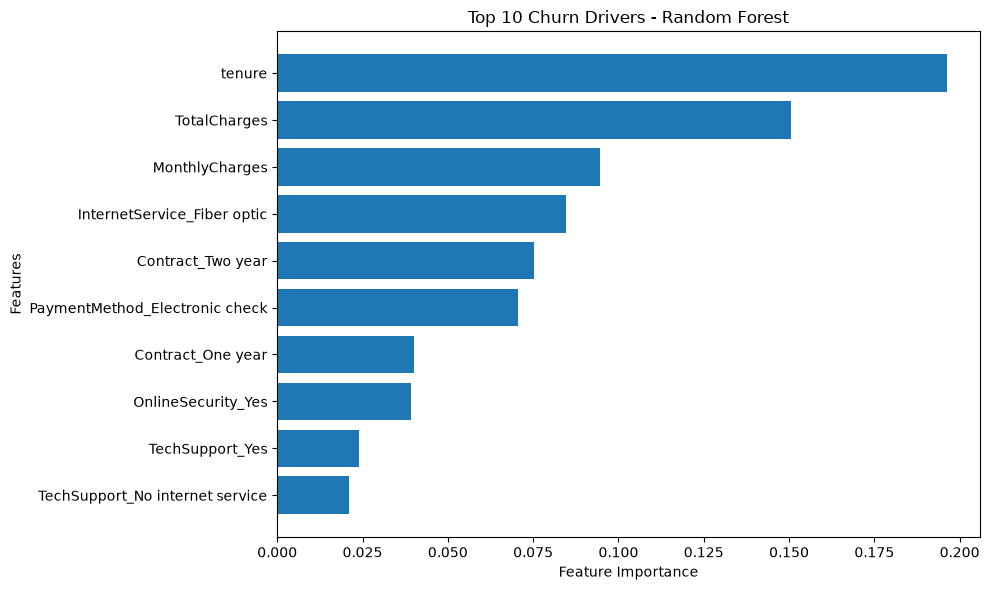

In [93]:
# Vizualizing the top 10 Features

top_10_features = feature_importance_df.head(10)

# Create the figure
# Figsize controlesthe width and height 0of the chart

plt.figure(figsize = (10, 6))
plt.barh(
    top_10_features["Feature"][:: -1],
    top_10_features["Importance"][:: -1],
)
plt.title("Top 10 Churn Drivers - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [94]:
# Logistic Regression Coefficients

# Our logistic regression model learned a coefficient for every feature
# positive coefficient: Higher value ---> associated with higher predicted churn
# Negative coefficient: Higher value ---> associated with lower predicted churn

logistic_coefficients = logistic_model_scaled.coef_[0]

# Get the names of the features used by the model
logistic_feature_names = x_train.columns

# Create a DataFrame containing:
# 1. Feature name
# 2. Logistic Regression coefficient
logistic_coefficients_df = pd.DataFrame({
    "Feature": logistic_feature_names,
    "Coefficient": logistic_coefficients
})


# Create another column containing the absolute value
# of each coefficient.
#
# Why?
# ----------------
# A coefficient can be positive or negative.
# Absolute value lets us compare the strength
# without considering the direction.

logistic_coefficients_df["Absolute_Coefficient"] = (
    logistic_coefficients_df["Coefficient"].abs()
)

# Sort the features from strongest to weakest
# based on the absolute coefficient.
logistic_coefficient_df = logistic_coefficients_df.sort_values(
    by = "Absolute_Coefficient",
    ascending = False
)

# Reset the index after sorting
logestic_coefficients_df = logistic_coefficients_df.reset_index(drop = True)

# Display the complete table
print("Logestic Regression Feature Coefficients:")
print(logistic_coefficients_df)

Logestic Regression Feature Coefficients:
                                  Feature  Coefficient  Absolute_Coefficient
0                           SeniorCitizen     0.053073              0.053073
1                                  tenure    -1.236528              1.236528
2                          MonthlyCharges    -0.920153              0.920153
3                            TotalCharges     0.514285              0.514285
4                             gender_Male     0.011094              0.011094
5                             Partner_Yes     0.010866              0.010866
6                          Dependents_Yes    -0.103550              0.103550
7                        PhoneService_Yes     0.006794              0.006794
8          MultipleLines_No phone service    -0.006794              0.006794
9                       MultipleLines_Yes     0.216167              0.216167
10            InternetService_Fiber optic     0.776154              0.776154
11                     InternetSer

In [95]:
# Churn drives
# Separate positive and negative drivers


# Positive churn Associations
positive_drivers = logistic_coefficients_df[
    logistic_coefficients_df["Coefficient"] > 0
]

# Sort from the strongest positive coefficient
positive_drivers = positive_drivers.sort_values(
    by = "Coefficient",
    ascending = False
)

# Display the top 10 positive associations
print("Top 10 Positive Chufrn Associations:")
print(
    positive_drivers[
        ["Feature", "Coefficient"]
        ].head(10)
)

# Negative churn Associations
# Select only features with a negative coefficient

negative_drivers = logistic_coefficients_df[
    logistic_coefficients_df["Coefficient"] < 0
]

# Sort from the strongest negative coefficient
negative_drivers = negative_drivers.sort_values(
    by = "Coefficient",
    ascending = True
)

# Displau the top 10 negative associations
print("Top 10 Negative Associations:")
print(
    negative_drivers[
        ["Feature", "Coefficient"]
        ].head(10)
)

Top 10 Positive Chufrn Associations:
                           Feature  Coefficient
10     InternetService_Fiber optic     0.776154
3                     TotalCharges     0.514285
23             StreamingMovies_Yes     0.257227
21                 StreamingTV_Yes     0.257144
9                MultipleLines_Yes     0.216167
26            PaperlessBilling_Yes     0.182034
28  PaymentMethod_Electronic check     0.181103
0                    SeniorCitizen     0.053073
17            DeviceProtection_Yes     0.053048
29      PaymentMethod_Mailed check     0.032262
Top 10 Negative Associations:
                                Feature  Coefficient
1                                tenure    -1.236528
2                        MonthlyCharges    -0.920153
25                    Contract_Two year    -0.586859
24                    Contract_One year    -0.285509
13                   OnlineSecurity_Yes    -0.123561
6                        Dependents_Yes    -0.103550
19                      TechSuppor

In [96]:
# Customer churn prediction + retention logic
# Predict churn probability for every customer

# Scale all customers features
x_all_scaled = scaler.transform(x_encoded)

# Calculate churn probability
all_churn_probability = (
    logistic_model_scaled.predict_proba(x_all_scaled)[:, 1]
)

# Create a customer scoring table
Scored_customers = df.copy()

# Add the predicted churn probability to our customer table.
Scored_customers["Churn_Probability"] = all_churn_probability

# COnvert the probability into percentage
Scored_customers["Churn_Probability_percent"] = (
    Scored_customers["Churn_Probability"] * 100
)

# Display all the 10 customers with their calculated churn probability
print("Customer Churn Probability:")
print(
    Scored_customers[
        [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "Contract",
        "Churn_Probability",
        "Churn_Probability_percent"
        ]
    ].head(10)
)


Customer Churn Probability:
   customerID  tenure  MonthlyCharges        Contract  Churn_Probability  \
0  7590-VHVEG       1           29.85  Month-to-month           0.612471   
1  5575-GNVDE      34           56.95        One year           0.043878   
2  3668-QPYBK       2           53.85  Month-to-month           0.301247   
3  7795-CFOCW      45           42.30        One year           0.028140   
4  9237-HQITU       2           70.70  Month-to-month           0.689928   
5  9305-CDSKC       8           99.65  Month-to-month           0.797081   
6  1452-KIOVK      22           89.10  Month-to-month           0.489267   
7  6713-OKOMC      10           29.75  Month-to-month           0.293762   
8  7892-POOKP      28          104.80  Month-to-month           0.624175   
9  6388-TABGU      62           56.15        One year           0.010502   

   Churn_Probability_percent  
0                  61.247092  
1                   4.387822  
2                  30.124715  
3          

In [97]:
# Customer churn prediction + retention logic
# Create customer risk levels

#  Our business thresholds are:
#
# 70% or above  -> High Risk
# 40% to <70%  -> Medium Risk
# Below 40%    -> Low Risk

# Create a function that converts a churn probability in to risk catogery
def assign_risk_level(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >=0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

# Apply the function to every customers churn probability
# The result will be stored in a new column called risk_level
Scored_customers["Risk_Level"] = (
    Scored_customers["Churn_Probability"]
    .apply(assign_risk_level)
)

# Display all the sample of customers with their probability and newly assigned risk level
print("Customer Risk Levels:")
print(
    Scored_customers[
        [
            "customerID",
            "Churn_Probability_percent",
            "Risk_Level"
        ]
        ].head(10)
)

Customer Risk Levels:
   customerID  Churn_Probability_percent   Risk_Level
0  7590-VHVEG                  61.247092  Medium Risk
1  5575-GNVDE                   4.387822     Low Risk
2  3668-QPYBK                  30.124715     Low Risk
3  7795-CFOCW                   2.813998     Low Risk
4  9237-HQITU                  68.992764  Medium Risk
5  9305-CDSKC                  79.708146    High Risk
6  1452-KIOVK                  48.926737  Medium Risk
7  6713-OKOMC                  29.376179     Low Risk
8  7892-POOKP                  62.417541  Medium Risk
9  6388-TABGU                   1.050168     Low Risk


In [98]:
# Customer churn prediction + retention
# Count customers by risk level
risk_counts = Scored_customers["Risk_Level"].value_counts()

# Display the number of customers in each category
print("Customers Risk Distribution:")
print(risk_counts)

# Calculate the percentage of customers
risk_percentages = (
    Scored_customers["Risk_Level"]
    .value_counts(normalize = True) * 100
)

# Display the percentage distribution
print("\nCustomer Risk Distribution (%):")
print(risk_percentages)

Customers Risk Distribution:
Risk_Level
Low Risk       4947
Medium Risk    1608
High Risk       488
Name: count, dtype: int64

Customer Risk Distribution (%):
Risk_Level
Low Risk       70.239955
Medium Risk    22.831180
High Risk       6.928866
Name: proportion, dtype: float64


In [99]:
# create retention actions

# create a function that assigns a retention action
# Based om the customers risk level

def assign_retention_action(risk_level):

    if risk_level == "High Risk":
        return "Immediate retention intervention"
    elif risk_level == "Medium Risk":
        return "Protective Engagement"
    else:
        return "Regular engagement"

# Apply the functions to every customers
Scored_customers["Retention_Action"] = (
    Scored_customers["Risk_Level"]
    .apply(assign_retention_action)
)

# Display a sample of customers showing the complete prediction and retention information
print("Customer Retention Recommendations:")
print(
    Scored_customers[
        [
            "customerID",
            "Churn_Probability_percent",
            "Risk_Level",
            "Retention_Action"
        ]
        ].head(15)
)

Customer Retention Recommendations:
    customerID  Churn_Probability_percent   Risk_Level  \
0   7590-VHVEG                  61.247092  Medium Risk   
1   5575-GNVDE                   4.387822     Low Risk   
2   3668-QPYBK                  30.124715     Low Risk   
3   7795-CFOCW                   2.813998     Low Risk   
4   9237-HQITU                  68.992764  Medium Risk   
5   9305-CDSKC                  79.708146    High Risk   
6   1452-KIOVK                  48.926737  Medium Risk   
7   6713-OKOMC                  29.376179     Low Risk   
8   7892-POOKP                  62.417541  Medium Risk   
9   6388-TABGU                   1.050168     Low Risk   
10  9763-GRSKD                  20.631848     Low Risk   
11  7469-LKBCI                   2.757352     Low Risk   
12  8091-TTVAX                  17.978010     Low Risk   
13  0280-XJGEX                  43.674940  Medium Risk   
14  5129-JLPIS                  46.155446  Medium Risk   

                    Retention_Actio

In [100]:
# IDentify higest_risk customers

higest_risk_customers = Scored_customers.sort_values(
    by = "Churn_Probability",
    ascending = False
)

# Churn probability according to our logistic regression model
top_20_risk_customers = higest_risk_customers.head(20)

# Display the most useful columns
print("Top 20 Higest_risk Customers:")
print(
    top_20_risk_customers[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "Contract",
            "Churn_Probability_percent",
            "Risk_Level",
            "Retention_Action"
        ]
    ]
)

Top 20 Higest_risk Customers:
      customerID  tenure  MonthlyCharges        Contract  \
1976  9497-QCMMS       1           93.55  Month-to-month   
4800  9300-AGZNL       1           94.00  Month-to-month   
3380  5178-LMXOP       1           95.10  Month-to-month   
3749  4424-TKOPW       2           93.85  Month-to-month   
6368  2720-WGKHP       2           94.00  Month-to-month   
1410  7024-OHCCK       2           93.85  Month-to-month   
5989  5567-WSELE       3           94.60  Month-to-month   
3159  5150-ITWWB       3           94.85  Month-to-month   
2208  7216-EWTRS       1          100.80  Month-to-month   
997   1374-DMZUI       4           94.30  Month-to-month   
301   8098-LLAZX       4           95.45  Month-to-month   
3209  8149-RSOUN       1           93.85  Month-to-month   
2577  4910-GMJOT       1           94.60  Month-to-month   
6866  0295-PPHDO       1           95.45  Month-to-month   
2631  6861-XWTWQ       7           99.25  Month-to-month   
1148  7851

In [101]:
# High Risk customer summary
high_risk_customers = Scored_customers[
    Scored_customers["Risk_Level"] == "High Risk"
    ]

# Create a summary
high_risk_summary = pd.DataFrame({
    "High_Risk_Customers":[
        len(high_risk_customers)
    ],
    "Average_Churn_Probability":[
        high_risk_customers["Churn_Probability_percent"].mean()
    ],
    "Average_Tenure": [
        high_risk_customers["tenure"].mean()
    ],
    "Average_Monthly_Charges":[
        high_risk_customers["MonthlyCharges"].mean()
    ]
})

# Display the summary
print("High-Risk Customer Summary:")
print(high_risk_summary)

High-Risk Customer Summary:
   High_Risk_Customers  Average_Churn_Probability  Average_Tenure  \
0                  488                  75.078413        6.309426   

   Average_Monthly_Charges  
0                85.391598  


In [102]:
# Final customer scoring table

# Customer level chufrn analysis
customer_scoring_table = Scored_customers[
    [
        "customerID",
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "tenure",
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "Churn",
        "Churn_Probability",
        "Churn_Probability_percent",
        "Risk_Level",
        "Retention_Action"
    ]
].copy()

# Display the first 10 rows so we can verify that our final scoring table was created correctly
print("Final Customer Scoring Table:")
print(customer_scoring_table.head(10))

# Display the number of rows and columns
print("\nShape of final Customer Scoring Table:")
print(customer_scoring_table.shape)

Final Customer Scoring Table:
   customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0  7590-VHVEG  Female              0     Yes         No       1   
1  5575-GNVDE    Male              0      No         No      34   
2  3668-QPYBK    Male              0      No         No       2   
3  7795-CFOCW    Male              0      No         No      45   
4  9237-HQITU  Female              0      No         No       2   
5  9305-CDSKC  Female              0      No         No       8   
6  1452-KIOVK    Male              0      No        Yes      22   
7  6713-OKOMC  Female              0      No         No      10   
8  7892-POOKP  Female              0     Yes         No      28   
9  6388-TABGU    Male              0      No        Yes      62   

  InternetService OnlineSecurity TechSupport        Contract PaperlessBilling  \
0             DSL             No          No  Month-to-month              Yes   
1             DSL            Yes          No        One year          

In [103]:
# Export final customer scoring table
# We are going to save our final customer scoring table
# as a CSV file.
#
# Why?
# ------------------------------------------------------------
# This CSV will become one of the main data sources
# for our Power BI Command Center.
#
# It contains:
# - Customer information
# - Churn probability
# - Risk level
# - Retention action
# - Historical churn status


# Save the final scoring table as a CSV file.
#
# index=False prevents pandas from adding an extra
# row-number column to the CSV.

customer_scoring_table.to_csv(
    "customer_churn_scoring.csv",
    index = False
)

# print a configaration message
print("Customer scoring dta exported successfully!")

# Display the file name so we knoe exactly what we created
print("File name: customer_churn_scoring.csv")

Customer scoring dta exported successfully!
File name: customer_churn_scoring.csv


In [105]:
# Random Forest feture importance

# Create a DataFrame containing feature names
# and their Random Forest importance values.
rf_feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort the features from highest importance to lowest importance.
# This makes the most important churn drivers appear at the top.
rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display the complete feature importance table.
print("Random Forest Feature Importance:")
print(rf_feature_importance)

Random Forest Feature Importance:
                                  Feature  Importance
0                                  tenure    0.196151
1                            TotalCharges    0.150635
2                          MonthlyCharges    0.094593
3             InternetService_Fiber optic    0.084754
4                       Contract_Two year    0.075353
5          PaymentMethod_Electronic check    0.070422
6                       Contract_One year    0.040074
7                      OnlineSecurity_Yes    0.039189
8                         TechSupport_Yes    0.024003
9         TechSupport_No internet service    0.020956
10                   PaperlessBilling_Yes    0.020292
11   DeviceProtection_No internet service    0.018042
12    StreamingMovies_No internet service    0.013753
13     OnlineSecurity_No internet service    0.013054
14        StreamingTV_No internet service    0.012076
15                       OnlineBackup_Yes    0.012020
16       OnlineBackup_No internet service    0.0

In [106]:
# ============================================================
# EXPORT RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
# We are saving the feature-importance table as a CSV file.
#
# Why?
# ----
# We will import this CSV into Power BI on our
# "Churn Drivers" page.
#
# The file will contain:
# Feature  -> Name of the ML feature
# Importance -> How important that feature was to the
#               Random Forest model
# ============================================================

# Define the location where we want to save the CSV file.
# Our project data folder is being used for supporting datasets.
rf_importance_file = r"D:\Desktop\AI-Powered-Customer-Churn-Retention\data\random_forest_feature_importance.csv"

# Save the DataFrame as a CSV file.
# index=False prevents pandas from adding an unnecessary
# index column to our CSV file.
rf_feature_importance.to_csv(
    rf_importance_file,
    index=False
)

# Confirm that the export was successful.
print("Random Forest feature importance exported successfully!")
print("File location:")
print(rf_importance_file)

Random Forest feature importance exported successfully!
File location:
D:\Desktop\AI-Powered-Customer-Churn-Retention\data\random_forest_feature_importance.csv


In [109]:
# LOGISTIC REGRESSION COEFFICIENTS

# Create a DataFrame containing:
# Feature -> name of the feature
# Coefficient -> coefficient learned by Logistic Regression
logistic_coefficient_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": logistic_model_scaled.coef_[0]
})

# Create another column containing the absolute value of each coefficient.
logistic_coefficient_df["Absolute_Coefficient"] = (
    logistic_coefficient_df["Coefficient"].abs()
)

# Sort the table from the largest absolute coefficient to the smallest.
logistic_coefficient_df = logistic_coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

# Display the complete table.
print("Logistic Regression Feature Coefficients:")
print(logistic_coefficient_df)

Logistic Regression Feature Coefficients:
                                  Feature  Coefficient  Absolute_Coefficient
0                                  tenure    -1.236528              1.236528
1                          MonthlyCharges    -0.920153              0.920153
2             InternetService_Fiber optic     0.776154              0.776154
3                       Contract_Two year    -0.586859              0.586859
4                            TotalCharges     0.514285              0.514285
5                       Contract_One year    -0.285509              0.285509
6                     StreamingMovies_Yes     0.257227              0.257227
7                         StreamingTV_Yes     0.257144              0.257144
8                       MultipleLines_Yes     0.216167              0.216167
9                    PaperlessBilling_Yes     0.182034              0.182034
10         PaymentMethod_Electronic check     0.181103              0.181103
11                     OnlineSecur

In [110]:
# Define where the CSV file will be saved.
# We are keeping supporting ML-analysis files inside
# the project's data folder.
logistic_coefficients_file = (
    r"D:\Desktop\AI-Powered-Customer-Churn-Retention"
    r"\data\logistic_regression_coefficients.csv"
)

# Save the DataFrame as a CSV file.
#
# index=False prevents pandas from adding the DataFrame
# index as an extra column.
logistic_coefficient_df.to_csv(
    logistic_coefficients_file,
    index=False
)

# Confirm that the export was successful.
print("Logistic Regression coefficients exported successfully!")
print("File location:")
print(logistic_coefficients_file)

Logistic Regression coefficients exported successfully!
File location:
D:\Desktop\AI-Powered-Customer-Churn-Retention\data\logistic_regression_coefficients.csv
